In [1]:
#Libraries Installed
!pip install torch torchvision transformers datasets
!pip install roboflow opencv-python-headless matplotlib
!pip install accelerate -U
!pip install roboflow -q
!pip install -q transformers accelerate
!pip install -q opencv-python-headless pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import torch
import numpy as np
from torch.utils.data import DataLoader
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

GPU available: True
Device: Tesla T4


In [3]:
#Importing Libraries
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
print("All imports successful")
print("PyTorch version:", torch.__version__)
print("Transformers ready")

All imports successful
PyTorch version: 2.10.0+cu128
Transformers ready


In [ ]:
from roboflow import Roboflow
from google.colab import userdata

api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=api_key)

# Dataset 1 - Drywall (object detection format)
project1 = rf.workspace("objectdetect-pu6rn").project("drywall-join-detect")
dataset1 = project1.version(1).download("yolov8")

print("Dataset 1 downloaded")

# # Load API key 
# try:
#     from google.colab import userdata
#     api_key = userdata.get('ROBOFLOW_API_KEY')
#     print("Loaded from Colab Secrets")
# except:
#     api_key = "YOUR_API_KEY_HERE"  # reviewer can paste key 
#     print("Using hardcoded key - replace with your own from roboflow.com")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drywall-Join-Detect-1 in yolov8:: 100%|██████████| 2381/2381 [00:01<00:00, 2373.57it/s]


Dataset 1 downloaded


In [5]:
# Download cracks dataset - version 1
project2 = rf.workspace("anmols-workspace-dz1rp").project("cracks-3ii36-ufk1q")
dataset2 = project2.version(1).download("yolov8")

print("Dataset 2 downloaded")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cracks-1 in yolov8:: 100%|██████████| 10749/10749 [00:01<00:00, 5552.46it/s]

Dataset 2 downloaded


In [6]:
import os

def count_images(base_path):
    found = False
    for split in ["train", "valid", "test"]:
        path = f"{base_path}/{split}/images"
        if os.path.exists(path):
            imgs = [f for f in os.listdir(path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
            print(f"  {split}: {len(imgs)} images")
            found = True
    if not found:
        print(f"  Could not find folder: {base_path}")

print("=== Dataset 1 - Drywall Taping ===")
count_images("Drywall-Join-Detect-1")

print("\n=== Dataset 2 - Cracks ===")
count_images("cracks-1")

=== Dataset 1 - Drywall Taping ===
  train: 936 images
  valid: 250 images

=== Dataset 2 - Cracks ===
  train: 5164 images
  valid: 201 images
  test: 4 images


In [7]:
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load CLIPSeg processor and model
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
model = model.to(device)
model.eval()

print("CLIPSeg model loaded ✓")

Using device: cuda



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSeg model loaded ✓


In [8]:

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, label_dir, prompt, img_size=352):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.prompt = prompt
        self.img_size = img_size
        self.images = [f for f in os.listdir(image_dir)
                      if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    def __len__(self):
        return len(self.images)

    def yolo_to_mask(self, label_path, img_w, img_h):
        """converting of YOLO bounding box to binary mask"""
        mask = np.zeros((img_h, img_w), dtype=np.uint8)
        if not os.path.exists(label_path):
            return mask
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = int((cx - bw/2) * img_w)
                y1 = int((cy - bh/2) * img_h)
                x2 = int((cx + bw/2) * img_w)
                y2 = int((cy + bh/2) * img_h)
                mask[y1:y2, x1:x2] = 255
        return mask

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # load and resize image
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size
        image = image.resize((self.img_size, self.img_size))

        # load corresponding label
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        mask = self.yolo_to_mask(label_path, orig_w, orig_h)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 127).astype(np.float32)

        return image, mask, self.prompt, img_name

print("Dataset class defined")

Dataset class defined


In [9]:
# drywall dataset
drywall_train = SegmentationDataset(
    image_dir="Drywall-Join-Detect-1/train/images",
    label_dir="Drywall-Join-Detect-1/train/labels",
    prompt="segment taping area"
)

drywall_val = SegmentationDataset(
    image_dir="Drywall-Join-Detect-1/valid/images",
    label_dir="Drywall-Join-Detect-1/valid/labels",
    prompt="segment taping area"
)

# cracks dataset
cracks_train = SegmentationDataset(
    image_dir="cracks-1/train/images",
    label_dir="cracks-1/train/labels",
    prompt="segment crack"
)

cracks_val = SegmentationDataset(
    image_dir="cracks-1/valid/images",
    label_dir="cracks-1/valid/labels",
    prompt="segment crack"
)

print(f"Drywall train: {len(drywall_train)} | val: {len(drywall_val)}")
print(f"Cracks  train: {len(cracks_train)} | val: {len(cracks_val)}")
print("Datasets ready")

Drywall train: 936 | val: 250
Cracks  train: 5164 | val: 201
Datasets ready


In [10]:
from torch.utils.data import ConcatDataset

# combining both datasets
combined_train = ConcatDataset([drywall_train, cracks_train])
combined_val = ConcatDataset([drywall_val, cracks_val])

print("Combined train size:", len(combined_train))
print("Combined val size:", len(combined_val))

Combined train size: 6100
Combined val size: 451


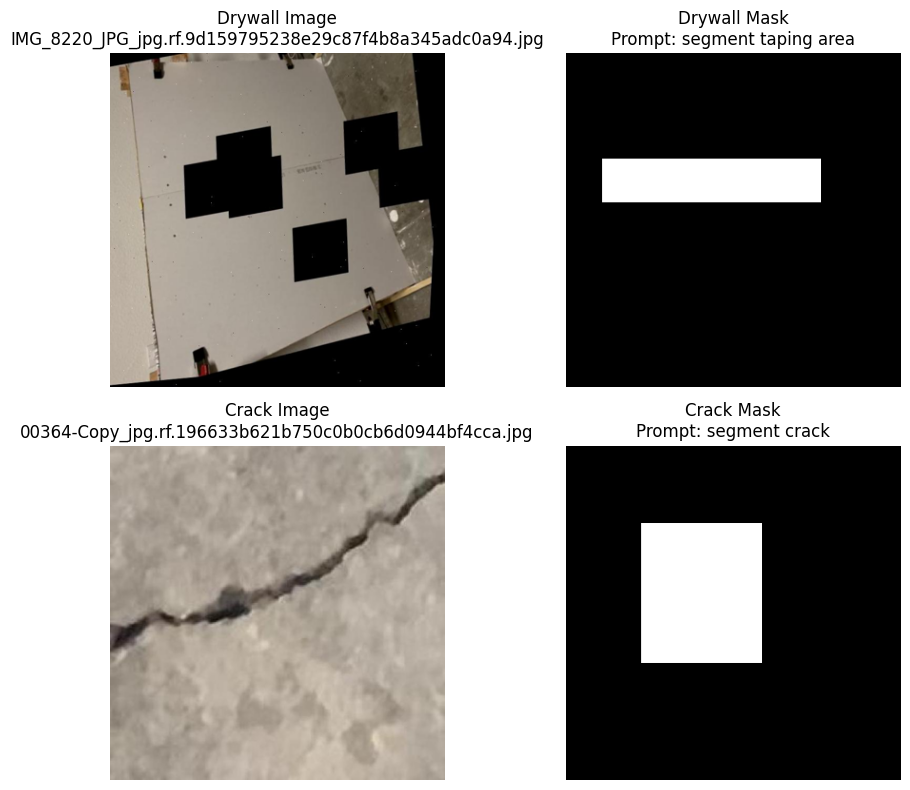

Sanity check done


In [11]:
# check one sample from each dataset
img1, mask1, prompt1, name1 = drywall_train[0]
img2, mask2, prompt2, name2 = cracks_train[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(img1); axes[0,0].set_title(f"Drywall Image\n{name1}")
axes[0,1].imshow(mask1, cmap='gray'); axes[0,1].set_title(f"Drywall Mask\nPrompt: {prompt1}")
axes[1,0].imshow(img2); axes[1,0].set_title(f"Crack Image\n{name2}")
axes[1,1].imshow(mask2, cmap='gray'); axes[1,1].set_title(f"Crack Mask\nPrompt: {prompt2}")

for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.savefig("sanity_check.png", dpi=100, bbox_inches='tight')
plt.show()
print("Sanity check done")

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    if union == 0:
        return 1.0
    return (intersection / union).item()

def dice_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    if pred.sum() + target.sum() == 0:
        return 1.0
    return (2. * intersection / (pred.sum() + target.sum())).item()

def combined_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    d_loss = dice_loss(pred, target)
    return bce + d_loss

print("Loss functions defined")

Loss functions defined


In [13]:
from torch.utils.data import DataLoader, ConcatDataset
from transformers import CLIPSegProcessor
import torch.optim as optim

def collate_fn(batch):
    images, masks, prompts, names = zip(*batch)
    masks = torch.stack([torch.tensor(m) for m in masks])
    return list(images), masks, list(prompts), list(names)

def train_one_epoch(model, processor, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for images, masks, prompts, _ in dataloader:
        inputs = processor(
            text=list(prompts),
            images=list(images),
            return_tensors="pt",
            padding=True
        ).to(device)

        masks = masks.to(device)

        outputs = model(**inputs)
        logits = outputs.logits

        logits = F.interpolate(
            logits.unsqueeze(1),
            size=(352, 352),
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        loss = combined_loss(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, processor, dataloader, device):
    model.eval()
    total_iou = 0
    total_dice = 0
    count = 0
    with torch.no_grad():
        for images, masks, prompts, _ in dataloader:
            inputs = processor(
                text=list(prompts),
                images=list(images),
                return_tensors="pt",
                padding=True
            ).to(device)
            masks = masks.to(device)
            outputs = model(**inputs)
            logits = outputs.logits
            logits = F.interpolate(
                logits.unsqueeze(1),
                size=(352, 352),
                mode='bilinear',
                align_corners=False
            ).squeeze(1)
            for i in range(logits.shape[0]):
                total_iou += iou_score(logits[i], masks[i])
                total_dice += dice_score(logits[i], masks[i])
                count += 1
    return total_iou / count, total_dice / count

print("Training functions updated")

Training functions updated


In [14]:
# set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

from torch.utils.data import ConcatDataset

# combine both datasets
combined_train = ConcatDataset([drywall_train, cracks_train])
combined_val = ConcatDataset([drywall_val, cracks_val])

print("Combined train size:", len(combined_train))
print("Combined val size:", len(combined_val))

combined_train_loader = DataLoader(
    combined_train,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

combined_val_loader = DataLoader(
    combined_val,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Combined dataloaders ready")

Combined train size: 6100
Combined val size: 451
Combined dataloaders ready


In [15]:
import time
import torch.optim as optim

# optimizer
optimizer = optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-4)

EPOCHS = 15
best_iou = 0

print("=" * 50)
print("Training on COMBINED datasets (prompts mixed)")
print("=" * 50)

train_start = time.time()

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        processor,
        combined_train_loader,
        optimizer,
        device
    )

    val_iou, val_dice = evaluate(
        model,
        processor,
        combined_val_loader,
        device
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_combined_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

train_time = time.time() - train_start

print(f"\nBest Val IoU: {best_iou:.4f}")
print(f"Training time: {train_time/60:.1f} minutes")

Training on COMBINED datasets (prompts mixed)
Epoch 1/15 | Loss: 1.2273 | Val IoU: 0.0633 | Val Dice: 0.0941
Epoch 2/15 | Loss: 1.1691 | Val IoU: 0.0908 | Val Dice: 0.1329
Epoch 3/15 | Loss: 1.1256 | Val IoU: 0.1052 | Val Dice: 0.1524
Epoch 4/15 | Loss: 1.0967 | Val IoU: 0.1120 | Val Dice: 0.1608
Epoch 5/15 | Loss: 1.0750 | Val IoU: 0.1230 | Val Dice: 0.1751
Epoch 6/15 | Loss: 1.0570 | Val IoU: 0.1297 | Val Dice: 0.1834
Epoch 7/15 | Loss: 1.0398 | Val IoU: 0.1352 | Val Dice: 0.1909
Epoch 8/15 | Loss: 1.0263 | Val IoU: 0.1433 | Val Dice: 0.2019
Epoch 9/15 | Loss: 1.0123 | Val IoU: 0.1599 | Val Dice: 0.2247
Epoch 10/15 | Loss: 1.0003 | Val IoU: 0.1751 | Val Dice: 0.2461
Epoch 11/15 | Loss: 0.9865 | Val IoU: 0.1977 | Val Dice: 0.2776
Epoch 12/15 | Loss: 0.9776 | Val IoU: 0.2131 | Val Dice: 0.2992
Epoch 13/15 | Loss: 0.9676 | Val IoU: 0.2326 | Val Dice: 0.3266
Epoch 14/15 | Loss: 0.9590 | Val IoU: 0.2527 | Val Dice: 0.3543
Epoch 15/15 | Loss: 0.9499 | Val IoU: 0.2713 | Val Dice: 0.3790

Be

In [16]:

# output directory for masks
os.makedirs("predictions", exist_ok=True)

def generate_masks(model, processor, dataset, model_path, device, prompt_tag):
    """Load best model and generate masks for all images"""

    # load best weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    torch.set_grad_enabled(False)

    inference_times = []

    for idx in range(len(dataset)):
        image, mask_gt, prompt, img_name = dataset[idx]

        # time inference
        start = time.time()

        inputs = processor(
            text=[prompt],
            images=[image],
            return_tensors="pt",
            padding=True
        ).to(device)

        outputs = model(**inputs)
        logits = outputs.logits

        logits = F.interpolate(
            logits.unsqueeze(1),
            size=(352, 352),
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        elapsed = time.time() - start
        inference_times.append(elapsed)

        # converting logits to probability map
        prob_map = torch.sigmoid(logits[0]).cpu().numpy()

        # threshold
        if "taping" in prompt_tag:
            pred_mask = (prob_map > 0.2).astype(np.uint8)
        else:
            pred_mask = (prob_map > 0.1).astype(np.uint8)

        # slight dilation to better overlap with bbox labels
        if "crack" in prompt_tag:
            pred_mask = cv2.dilate(pred_mask, np.ones((3,3), np.uint8), iterations=2)

        # convert to required format {0,255}
        pred_mask = (pred_mask * 255).astype(np.uint8)

        # save with required filename format
        img_id = os.path.splitext(img_name)[0]
        save_name = f"{img_id}__{prompt_tag}.png"
        save_path = os.path.join("predictions", save_name)

        Image.fromarray(pred_mask).save(save_path)

    avg_time = np.mean(inference_times)

    print(f"Generated {len(dataset)} masks")
    print(f"Avg inference time: {avg_time*1000:.1f} ms/image")

    return avg_time

print("Inference function defined")

Inference function defined


In [17]:
print("Generating Drywall masks")
drywall_avg_time = generate_masks(
    model=model,
    processor=processor,
    dataset=drywall_val,
    model_path="best_combined_model.pth",
    device=device,
    prompt_tag="segment_taping_area"
)

Generating Drywall masks
Generated 250 masks
Avg inference time: 25.8 ms/image


In [18]:
print("Generating Crack masks")
cracks_avg_time = generate_masks(
    model=model,
    processor=processor,
    dataset=cracks_val,
    model_path="best_combined_model.pth",
    device=device,
    prompt_tag="segment_crack"
)

Generating Crack masks
Generated 201 masks
Avg inference time: 25.9 ms/image


In [19]:
masks = os.listdir("predictions")
drywall_masks = [m for m in masks if "taping" in m]
crack_masks = [m for m in masks if "crack" in m]

print(f"Total masks generated: {len(masks)}")
print(f"  Drywall masks: {len(drywall_masks)}")
print(f"  Crack masks:   {len(crack_masks)}")
print(f"\nSample filenames:")
print(f"  {drywall_masks[0]}")
print(f"  {crack_masks[0]}")

Total masks generated: 451
  Drywall masks: 250
  Crack masks:   201

Sample filenames:
  IMG_8241_JPG_jpg.rf.8d402aec06484f5ded5062a90baddf6a__segment_taping_area.png
  303-dat_png_jpg.rf.cc629d8bb995874bf6ec13ef902db431__segment_crack.png


In [20]:
def compute_final_metrics(model, processor, dataset, model_path, device):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_iou = []
    all_dice = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, mask_gt, prompt, img_name = dataset[idx]

            inputs = processor(
                text=[prompt],
                images=[image],
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = model(**inputs)
            logits = outputs.logits
            logits = F.interpolate(
                logits.unsqueeze(1),
                size=(352, 352),
                mode='bilinear',
                align_corners=False
            ).squeeze(1)

            mask_tensor = torch.tensor(mask_gt).to(device)
            all_iou.append(iou_score(logits[0], mask_tensor))
            all_dice.append(dice_score(logits[0], mask_tensor))

    miou = np.mean(all_iou)
    mdice = np.mean(all_dice)
    return miou, mdice

print("Metrics function defined")

Metrics function defined


In [21]:
print("Computing Drywall metrics...")
drywall_miou, drywall_mdice = compute_final_metrics(
    model, processor, drywall_val, "best_combined_model.pth", device
)

print("Computing Cracks metrics...")
cracks_miou, cracks_mdice = compute_final_metrics(
    model, processor, cracks_val, "best_combined_model.pth", device
)

print("\n" + "="*55)
print(f"{'Prompt':<25} {'mIoU':>10} {'Dice':>10}")
print("="*55)
print(f"{'segment taping area':<25} {drywall_miou:>10.4f} {drywall_mdice:>10.4f}")
print(f"{'segment crack':<25} {cracks_miou:>10.4f} {cracks_mdice:>10.4f}")
print(f"{'Average':<25} {(drywall_miou+cracks_miou)/2:>10.4f} {(drywall_mdice+cracks_mdice)/2:>10.4f}")
print("="*55)

Computing Drywall metrics...
Computing Cracks metrics...

Prompt                          mIoU       Dice
segment taping area           0.2789     0.4032
segment crack                 0.2618     0.3489
Average                       0.2703     0.3760


In [22]:
def plot_visual_examples(model, processor, dataset, model_path,
                          device, title, n_samples=4):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Pick evenly spaced samples
    indices = np.linspace(0, len(dataset)-1, n_samples, dtype=int)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    col_titles = ['Original Image', 'Ground Truth Mask', 'Predicted Mask']
    for ax, col in zip(axes[0], col_titles):
        ax.set_title(col, fontsize=13, fontweight='bold')

    with torch.no_grad():
        for row, idx in enumerate(indices):
            image, mask_gt, prompt, img_name = dataset[idx]

            inputs = processor(
                text=[prompt],
                images=[image],
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = model(**inputs)
            logits = outputs.logits
            logits = F.interpolate(
                logits.unsqueeze(1),
                size=(352, 352),
                mode='bilinear',
                align_corners=False
            ).squeeze(1)

            prob_map = torch.sigmoid(logits[0]).cpu().numpy()
            if "taping" in prompt.lower():
                pred = (prob_map > 0.2)
            else:
                pred = (prob_map > 0.1)

            pred = (pred * 255).astype(np.uint8)

            axes[row, 0].imshow(image)
            axes[row, 0].set_ylabel(f"Sample {row+1}", fontsize=10)
            axes[row, 1].imshow(mask_gt, cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')

            for ax in axes[row]:
                ax.axis('off')

    plt.tight_layout()
    save_path = f"visuals_{title.replace(' ', '_').lower()}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Visual function defined")

Visual function defined


Generating Drywall visuals...


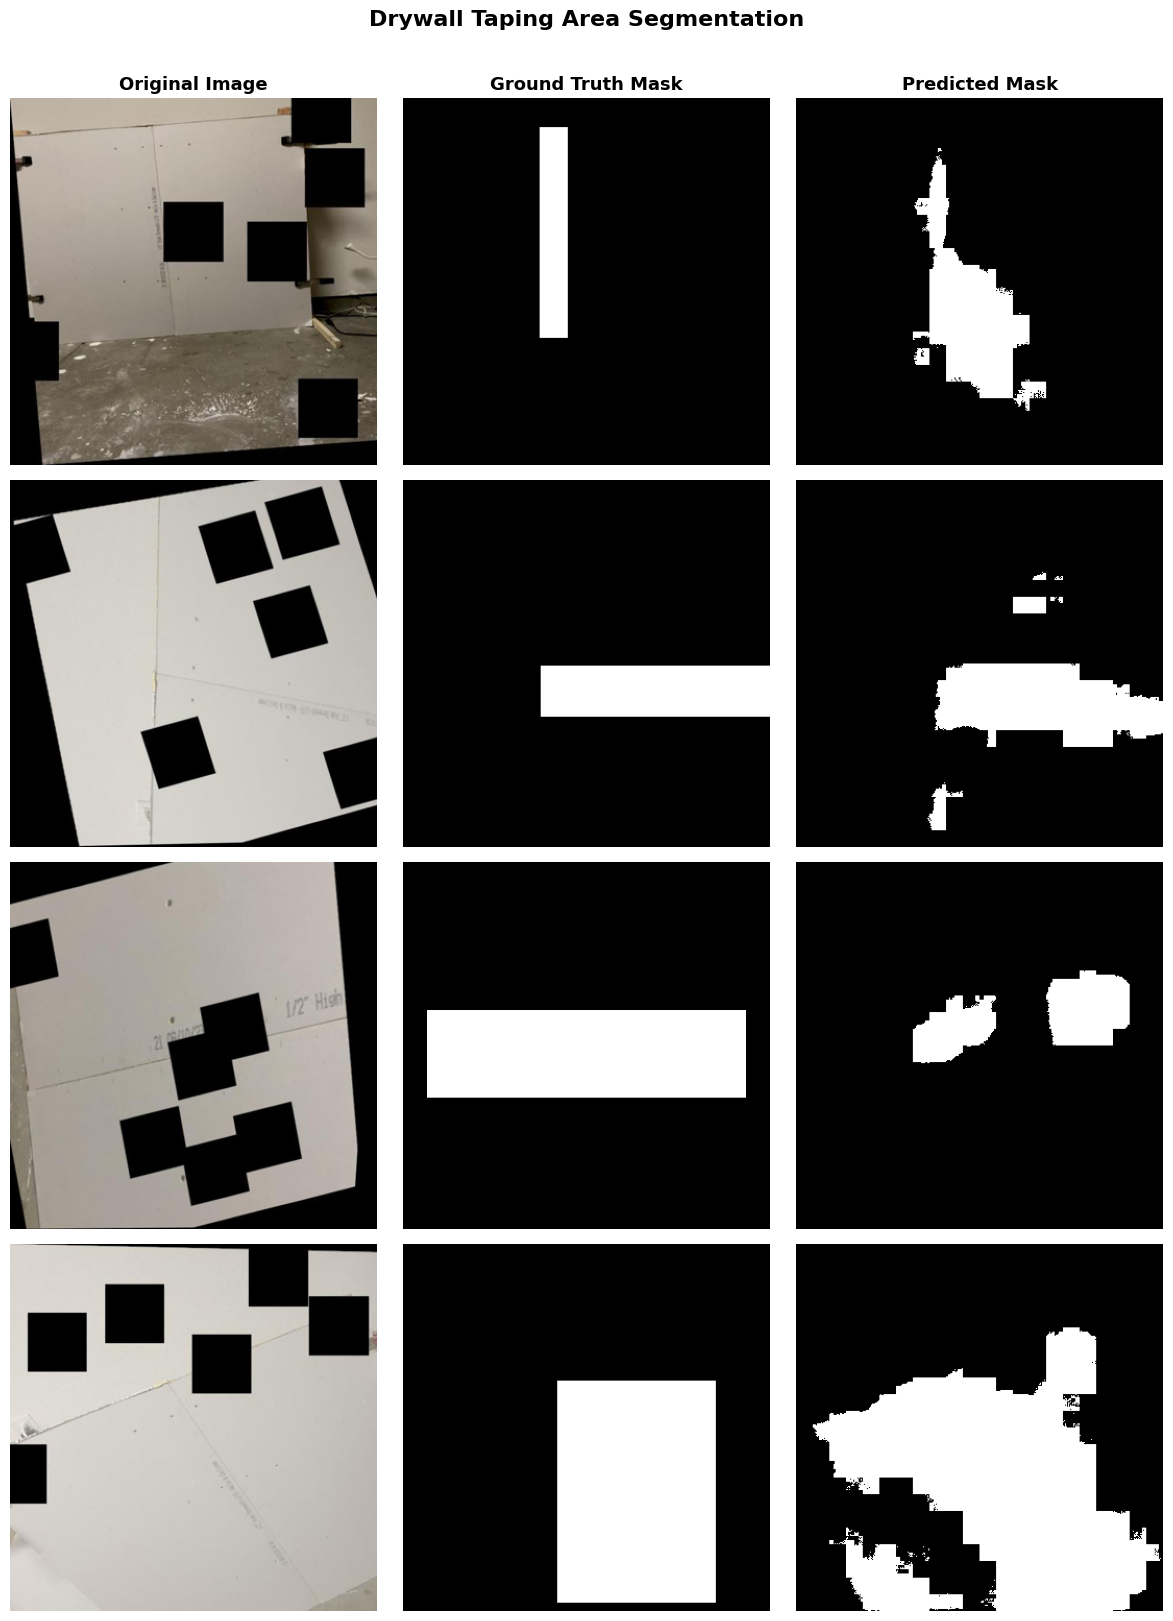

Saved: visuals_drywall_taping_area_segmentation.png

Generating Crack visuals...


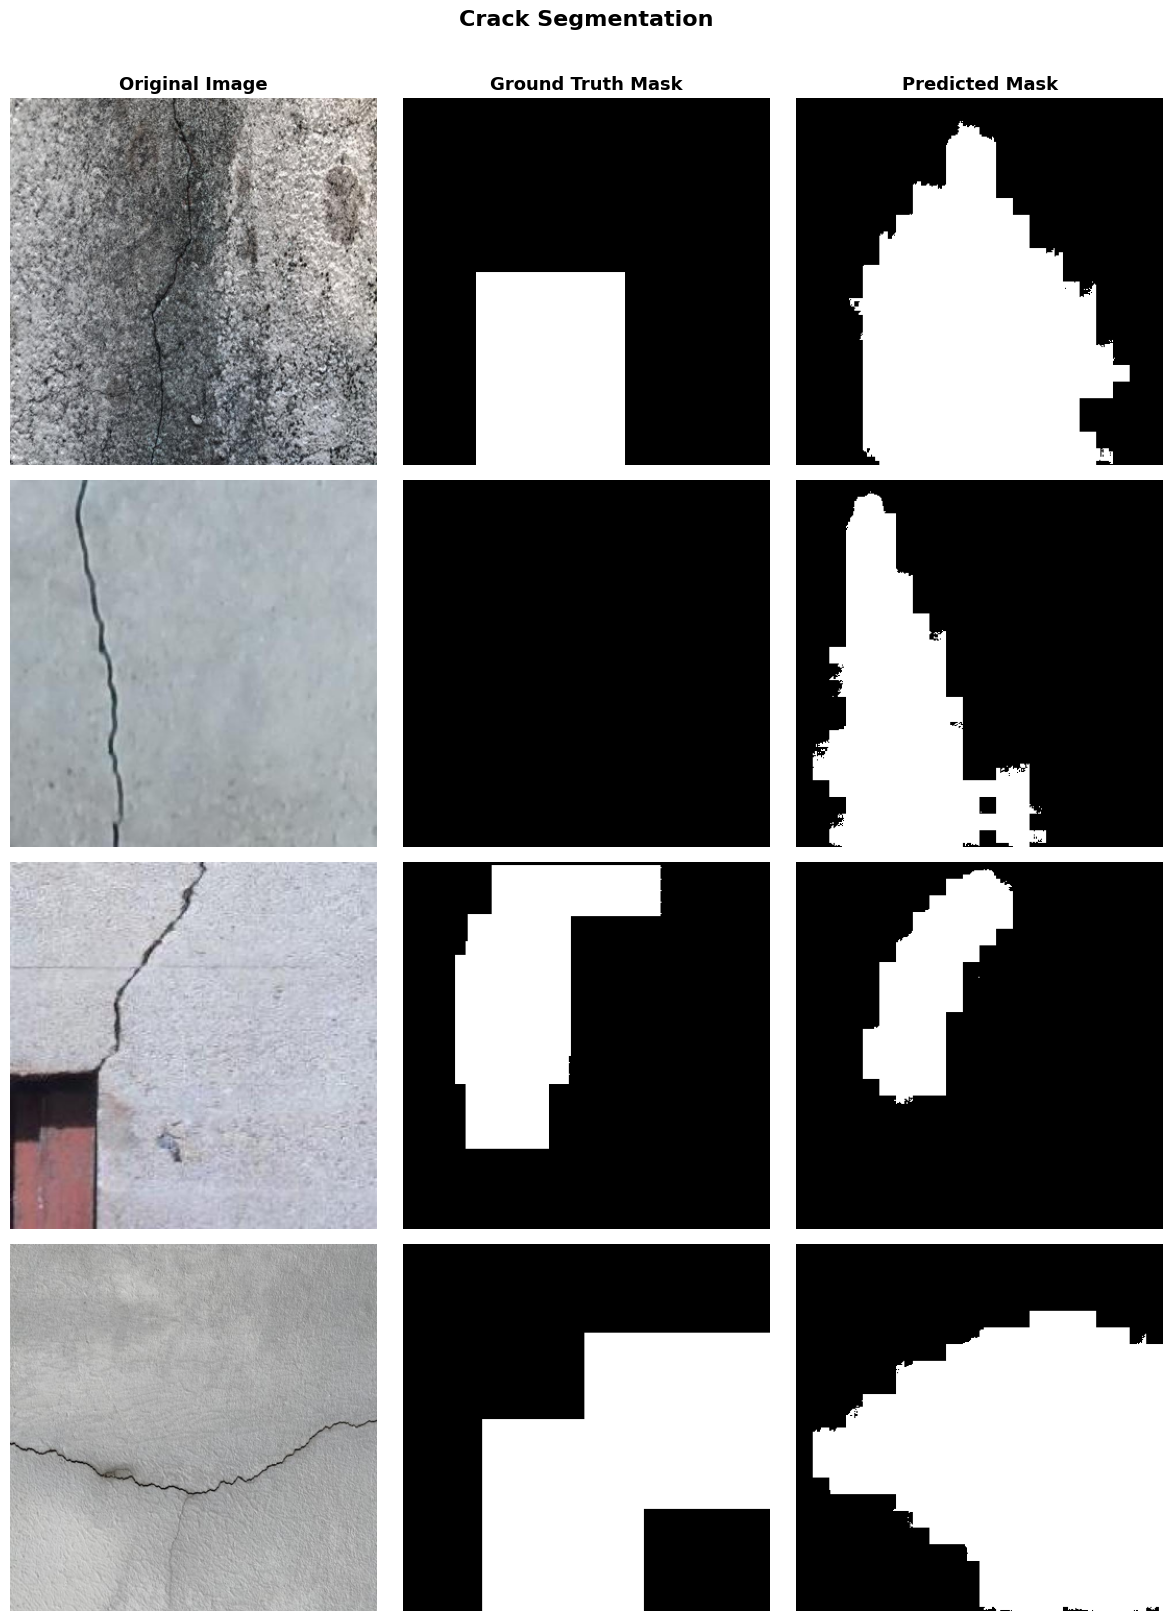

Saved: visuals_crack_segmentation.png


In [23]:
print("Generating Drywall visuals...")
plot_visual_examples(
    model, processor, drywall_val,
    "best_combined_model.pth", device,
    "Drywall Taping Area Segmentation"
)

print("\nGenerating Crack visuals...")
plot_visual_examples(
    model, processor, cracks_val,
    "best_combined_model.pth", device,
    "Crack Segmentation"
)

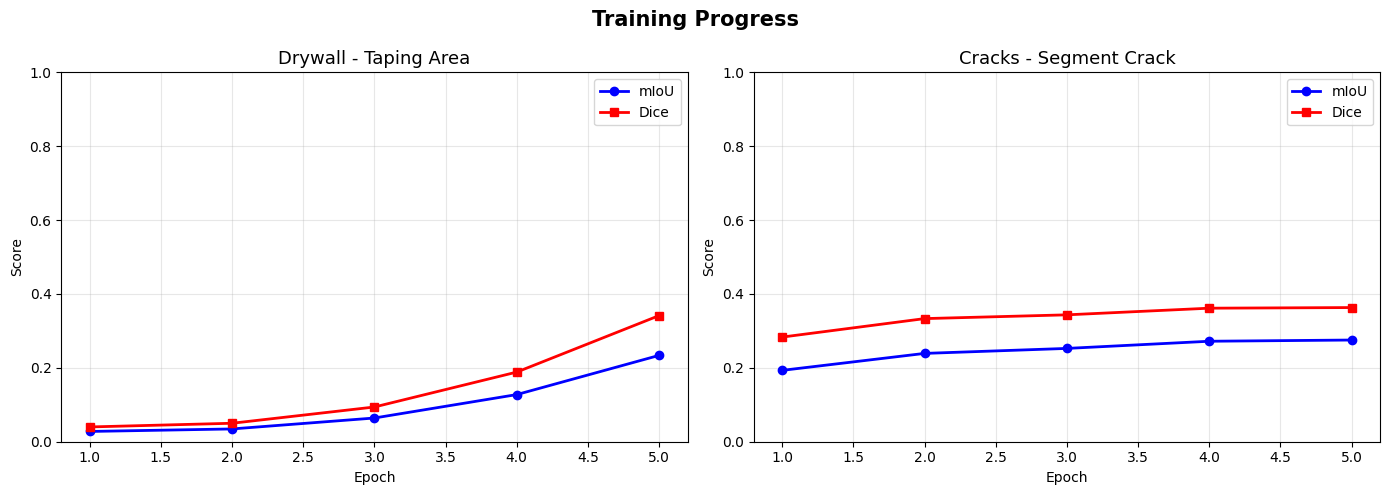

Training curves saved


In [24]:
drywall_iou_per_epoch = [0.0278, 0.0346, 0.0642, 0.1276, 0.2337]
drywall_dice_per_epoch = [0.0400, 0.0500, 0.0940, 0.1885, 0.3414]
cracks_iou_per_epoch = [0.1932, 0.2391, 0.2526, 0.2720, 0.2753]
cracks_dice_per_epoch = [0.2833, 0.3333, 0.3435, 0.3615, 0.3632]
epochs = list(range(1, 6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Progress", fontsize=15, fontweight='bold')

# Drywall
axes[0].plot(epochs, drywall_iou_per_epoch, 'b-o', label='mIoU', linewidth=2)
axes[0].plot(epochs, drywall_dice_per_epoch, 'r-s', label='Dice', linewidth=2)
axes[0].set_title("Drywall - Taping Area", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Cracks
axes[1].plot(epochs, cracks_iou_per_epoch, 'b-o', label='mIoU', linewidth=2)
axes[1].plot(epochs, cracks_dice_per_epoch, 'r-s', label='Dice', linewidth=2)
axes[1].set_title("Cracks - Segment Crack", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved")

In [25]:
# test different thresholds to find the best one
def evaluate_threshold(model, processor, dataset, model_path, device, thresholds):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    results = {}
    for thresh in thresholds:
        all_iou = []
        with torch.no_grad():
            for idx in range(min(50, len(dataset))):
                image, mask_gt, prompt, _ = dataset[idx]
                inputs = processor(
                    text=[prompt], images=[image],
                    return_tensors="pt", padding=True
                ).to(device)
                outputs = model(**inputs)
                logits = outputs.logits
                logits = F.interpolate(
                    logits.unsqueeze(1), size=(352, 352),
                    mode='bilinear', align_corners=False
                ).squeeze(1)
                pred = (torch.sigmoid(logits[0]) > thresh).float()
                mask_t = torch.tensor(mask_gt).to(device)
                intersection = (pred * mask_t).sum()
                union = pred.sum() + mask_t.sum() - intersection
                iou = (intersection / union).item() if union > 0 else 1.0
                all_iou.append(iou)
        results[thresh] = np.mean(all_iou)
        print(f"  Threshold {thresh:.2f} -> mIoU: {results[thresh]:.4f}")

    best_thresh = max(results, key=results.get)
    print(f"\nBest threshold: {best_thresh}")
    return best_thresh

print("Testing thresholds for Drywall...")
best_drywall_thresh = evaluate_threshold(
    model, processor, drywall_val,
    "best_combined_model.pth", device,
    [0.1, 0.2, 0.3, 0.4, 0.5]
)

print("\nTesting thresholds for Cracks...")
best_cracks_thresh = evaluate_threshold(
    model, processor, cracks_val,
    "best_combined_model.pth", device,
    [0.1, 0.2, 0.3, 0.4, 0.5]
)

Testing thresholds for Drywall...
  Threshold 0.10 -> mIoU: 0.2822
  Threshold 0.20 -> mIoU: 0.3122
  Threshold 0.30 -> mIoU: 0.3208
  Threshold 0.40 -> mIoU: 0.3046
  Threshold 0.50 -> mIoU: 0.2903

Best threshold: 0.3

Testing thresholds for Cracks...
  Threshold 0.10 -> mIoU: 0.3176
  Threshold 0.20 -> mIoU: 0.3039
  Threshold 0.30 -> mIoU: 0.2809
  Threshold 0.40 -> mIoU: 0.2520
  Threshold 0.50 -> mIoU: 0.2160

Best threshold: 0.1


In [26]:
from google.colab import files

# downloading model weights
files.download("best_combined_model.pth")

# downloading visuals
files.download("sanity_check.png")
files.download("training_curves.png")
files.download("visuals_drywall_taping_area_segmentation.png")
files.download("visuals_crack_segmentation.png")

# downloading notebook
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
